In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [4]:
df.columns

Index(['catcher_id', 'jobma_catcher_title', 'jobma_catcher_otype',
       'jobma_catcher_status', 'jobma_catcher_type', 'is_premium',
       'jobma_verified', 'subscription_status', 'sub_user', 'per_sub_user',
       'live_interview_credit', 'pre_recorded_credit',
       'ai_live_interview_credit', 'interview_cost_type', 'referral_credit',
       'company_size', 'ai_live_interview', 'days_since_creation', 'confirmed',
       'number_of_logins', 'credit_amount', 'wallet_amount', 'plan_type',
       'is_unlimited', 'trial_account_type', 'billing_cycle_status',
       'subscription_amount', 'credit_given', 'currency_val',
       'times_of_subscription', 'kits_count', 'position_created',
       'number_of_invitations', 'pitchers_counts', 'def_interview_counts',
       'interview_counts', 'ai_interview_counts'],
      dtype='object')

In [5]:
df.drop(columns=[#'sub_user',  ##As it has irrelevant data and very weak correlation with other table
                 'live_interview_credit', ##As it har irrelevant data and very weak correlation with other table
                 'pre_recorded_credit',
                 'ai_live_interview_credit',#As it has strong correlation 1
                 'referral_credit'], #has 200,400,600,44000==1 or 2, almost all are 0 and has strong correlation with ai_kit_count of 1
        inplace=True)
df.shape

(5529, 33)

In [6]:
df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes
df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)

In [7]:
df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})
df['sub_user'] = df['sub_user'].apply(lambda x: 1000 if x > 1000 else x)      #To handele extreme outlier

In [8]:
df.shape

(5529, 45)

In [9]:
# Converting df to tensor and Preprocess

In [10]:
X = df.values
scaler = RobustScaler()

In [11]:
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [12]:
# Autoencoder for robustness
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, latent_dim=10):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        

    def forward(self, x):
        z = self.encoder(x)
        x_bar = self.decoder(z)
        return x_bar, z

In [13]:
# Pretraining Autoencoder
input_dim = X_scaled.shape[1]
autoencoder = AutoEncoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.SmoothL1Loss()  # More robust than MSE with 

In [14]:
#Pretraining Autoencoder
for epoch in range(50):
    autoencoder.train()
    total_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)
        x_bar, _ = autoencoder(x_batch)
        loss = criterion(x_bar, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Pretrain] Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

[Pretrain] Epoch 1, Loss: 6.1154
[Pretrain] Epoch 2, Loss: 6.0559
[Pretrain] Epoch 3, Loss: 5.9657
[Pretrain] Epoch 4, Loss: 5.8427
[Pretrain] Epoch 5, Loss: 5.7219
[Pretrain] Epoch 6, Loss: 3.7979
[Pretrain] Epoch 7, Loss: 3.7691
[Pretrain] Epoch 8, Loss: 3.5608
[Pretrain] Epoch 9, Loss: 3.1633
[Pretrain] Epoch 10, Loss: 3.0185
[Pretrain] Epoch 11, Loss: 3.2567
[Pretrain] Epoch 12, Loss: 2.1361
[Pretrain] Epoch 13, Loss: 2.0653
[Pretrain] Epoch 14, Loss: 1.9031
[Pretrain] Epoch 15, Loss: 1.8365
[Pretrain] Epoch 16, Loss: 1.4565
[Pretrain] Epoch 17, Loss: 1.1838
[Pretrain] Epoch 18, Loss: 1.4794
[Pretrain] Epoch 19, Loss: 0.9375
[Pretrain] Epoch 20, Loss: 1.5109
[Pretrain] Epoch 21, Loss: 1.1736
[Pretrain] Epoch 22, Loss: 1.0003
[Pretrain] Epoch 23, Loss: 0.8496
[Pretrain] Epoch 24, Loss: 1.0740
[Pretrain] Epoch 25, Loss: 0.9838
[Pretrain] Epoch 26, Loss: 1.1032
[Pretrain] Epoch 27, Loss: 1.2541
[Pretrain] Epoch 28, Loss: 0.9750
[Pretrain] Epoch 29, Loss: 1.6053
[Pretrain] Epoch 30, Lo

In [15]:
# Extract Latent Features
autoencoder.eval()
with torch.no_grad():
    _, latent = autoencoder(X_tensor.to(device))
latent_np = latent.cpu().numpy()

In [16]:
# Determine Optimal Cluster Count   #Finding optimal number of clusters using Silhouette Score
scores = []
K_range = range(2, 15)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(latent_np)
    score = silhouette_score(latent_np, labels)
    scores.append(score)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

Clusters: 2, Silhouette Score: 0.9965
Clusters: 3, Silhouette Score: 0.9700
Clusters: 4, Silhouette Score: 0.9129
Clusters: 5, Silhouette Score: 0.9138
Clusters: 6, Silhouette Score: 0.9023
Clusters: 7, Silhouette Score: 0.8117
Clusters: 8, Silhouette Score: 0.8598
Clusters: 9, Silhouette Score: 0.8708
Clusters: 10, Silhouette Score: 0.8839
Clusters: 11, Silhouette Score: 0.8850
Clusters: 12, Silhouette Score: 0.8866
Clusters: 13, Silhouette Score: 0.8871
Clusters: 14, Silhouette Score: 0.8900


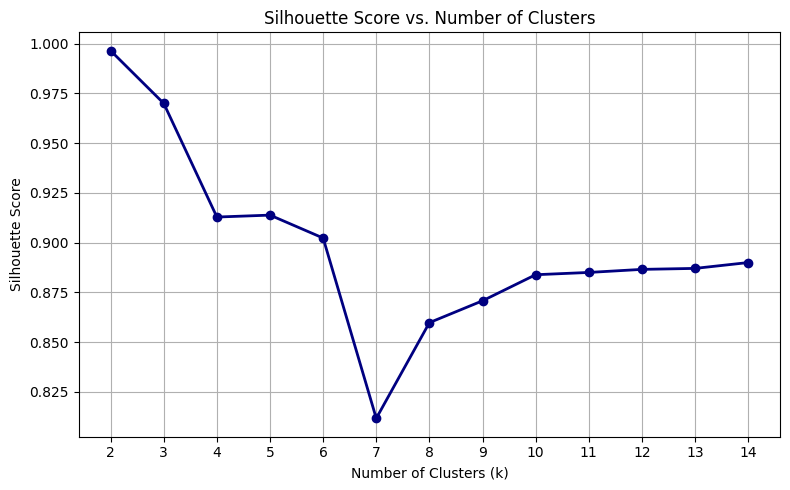

In [17]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(K_range, scores, marker='o', color='navy', linewidth=2)
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
#Initialising KMeans
kmeans = KMeans(n_clusters=5, n_init=20)
cluster_ids = kmeans.fit_predict(latent_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

In [19]:
# Deep Embedding Clusturing Model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()  

#Train DEC
dec = DEC(autoencoder.encoder, cluster_centers.clone()).to(device)
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-3)

In [20]:
#Training DEC (with reconstruction loss)

In [21]:
for epoch in range(50):
    dec.train()
    total_loss = 0
    all_q = []

    for batch in dataloader:
        x = batch[0].to(device)
        q, _ = dec(x)
        all_q.append(q.detach().cpu())
    q_all = torch.cat(all_q, dim=0)
    p_all = target_distribution(q_all)

    entropy = -torch.sum(q_all * torch.log(q_all + 1e-10)) / q_all.size(0)

    idx = 0
    for batch in dataloader:
        x = batch[0].to(device)
        q, z = dec(x)
        p = p_all[idx:idx + len(x)].to(device)
        kl_loss = F.kl_div(q.log(), p, reduction='batchmean')
        x_bar = autoencoder.decoder(z)
        recon_loss = F.smooth_l1_loss(x_bar, x)
        loss = kl_loss + 0.1 * recon_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        idx += len(x)
        total_loss += loss.item()

    print(f"[DEC] Epoch {epoch+1}, KL Loss: {total_loss/len(dataloader):.4f}, Entropy: {entropy:.4f}")

[DEC] Epoch 1, KL Loss: 0.3368, Entropy: 0.0473
[DEC] Epoch 2, KL Loss: 0.3366, Entropy: 0.0498
[DEC] Epoch 3, KL Loss: 0.3353, Entropy: 0.0534
[DEC] Epoch 4, KL Loss: 0.3293, Entropy: 0.0551
[DEC] Epoch 5, KL Loss: 0.3173, Entropy: 0.0557
[DEC] Epoch 6, KL Loss: 0.3277, Entropy: 0.0558
[DEC] Epoch 7, KL Loss: 0.3252, Entropy: 0.0561
[DEC] Epoch 8, KL Loss: 0.3181, Entropy: 0.0573
[DEC] Epoch 9, KL Loss: 0.3214, Entropy: 0.0572
[DEC] Epoch 10, KL Loss: 0.3157, Entropy: 0.0575
[DEC] Epoch 11, KL Loss: 0.3265, Entropy: 0.0571
[DEC] Epoch 12, KL Loss: 0.3168, Entropy: 0.0583
[DEC] Epoch 13, KL Loss: 0.3152, Entropy: 0.0589
[DEC] Epoch 14, KL Loss: 0.3136, Entropy: 0.0601
[DEC] Epoch 15, KL Loss: 0.3106, Entropy: 0.0606
[DEC] Epoch 16, KL Loss: 0.3155, Entropy: 0.0601
[DEC] Epoch 17, KL Loss: 0.3230, Entropy: 0.0615
[DEC] Epoch 18, KL Loss: 0.3235, Entropy: 0.0623
[DEC] Epoch 19, KL Loss: 0.3122, Entropy: 0.0574
[DEC] Epoch 20, KL Loss: 0.3049, Entropy: 0.0600
[DEC] Epoch 21, KL Loss: 0.31

In [22]:
#Final Prediction
dec.eval()
with torch.no_grad():
    q, _ = dec(X_tensor.to(device))
    preds = torch.argmax(q, dim=1).cpu().numpy()

df['dec_cluster'] = preds
print("Clustering complete")

Clustering complete


In [23]:
df['dec_cluster'].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: dec_cluster, dtype: int64

In [24]:
#Visualizing clusters with t-SNE..

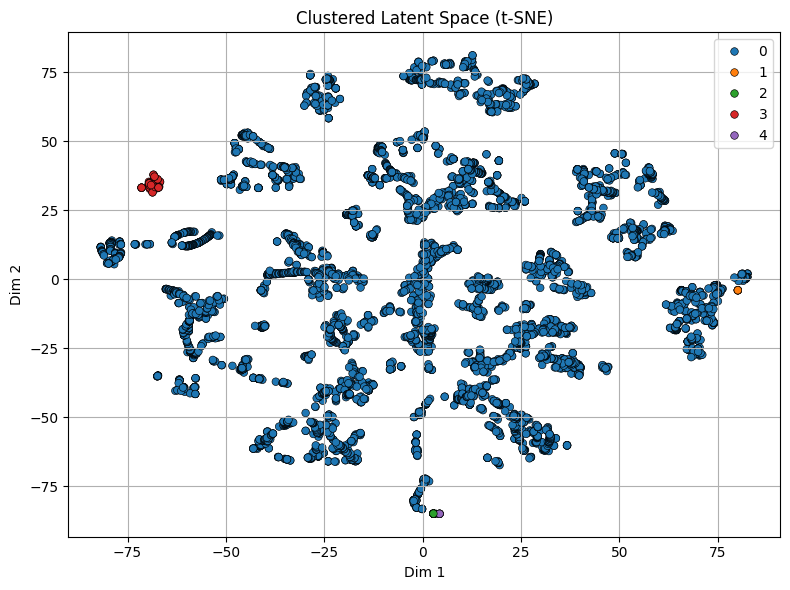

In [25]:
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_np)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=preds, palette='tab10', s=30, edgecolor='k')
plt.title("Clustered Latent Space (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
sil_score = silhouette_score(latent_np, preds)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.9138327240943909


In [27]:
# Checking the size of each cluster
cluster_sizes = pd.Series(preds).value_counts()
cluster_sizes

0    5447
3      57
2      15
4       5
1       5
Name: count, dtype: int64

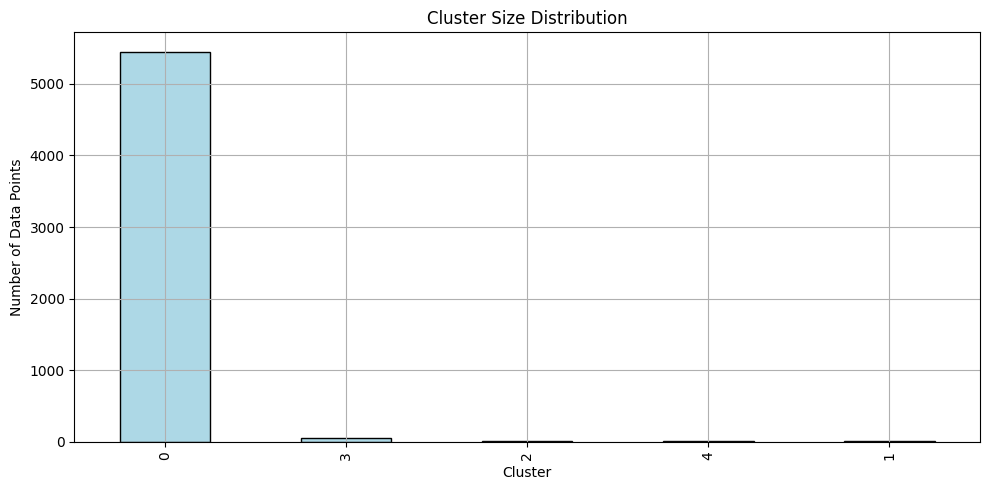

In [28]:
# Visualize the cluster distribution
plt.figure(figsize=(10, 5))
cluster_sizes.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")
plt.grid(True)
plt.tight_layout()
plt.show()